In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

Step 2 — Load Processed Dataset

In [2]:
X_train = np.load("../Processed_Data/X_train.npy")
X_val   = np.load("../Processed_Data/X_val.npy")
X_test  = np.load("../Processed_Data/X_test.npy")

y_train = np.load("../Processed_Data/y_train.npy")
y_val   = np.load("../Processed_Data/y_val.npy")
y_test  = np.load("../Processed_Data/y_test.npy")

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(583, 14, 512)
(184, 14, 512)
(222, 14, 512)


Step 3 — Convert to PyTorch

In [3]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

Step 4 — Create DataLoaders

In [4]:
batch_size = 32

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=batch_size,
    shuffle=False
)

Step 5 — Install snnTorch

In [5]:
!pip install snntorch

Defaulting to user installation because normal site-packages is not writeable


Step 6 — Import snnTorch

In [6]:
import snntorch as snn

from snntorch import surrogate
from snntorch import functional as SF

In [7]:
print(torch.__version__)

import snntorch

print(snntorch.__version__)

2.11.0+cpu
1.0.0


Step 8: Define Device

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


Step 9: Define SNN Hyperparameters

In [9]:
# Network parameters
num_inputs = 14 * 512      # Flattened EEG window
num_hidden = 256
num_outputs = 2

# Spiking parameters
beta = 0.95                # Membrane decay
num_steps = 20             # Simulation time steps

Step 10: Build the Spiking Neural Network

In [10]:
import snntorch as snn
from snntorch import surrogate

spike_grad = surrogate.fast_sigmoid()

class EEGSNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(num_inputs, num_hidden)

        self.lif1 = snn.Leaky(
            beta=beta,
            spike_grad=spike_grad
        )

        self.fc2 = nn.Linear(num_hidden, num_outputs)

        self.lif2 = snn.Leaky(
            beta=beta,
            spike_grad=spike_grad
        )

    def forward(self, x):

        # Flatten EEG window
        x = x.view(x.size(0), -1)

        # Initialize membrane potentials
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        spk2_rec = []
        mem2_rec = []

        # Simulate over time
        for step in range(num_steps):

            cur1 = self.fc1(x)

            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)

            spk2, mem2 = self.lif2(cur2, mem2)

            spk2_rec.append(spk2)

            mem2_rec.append(mem2)

        # Stack outputs over time
        spk2_rec = torch.stack(spk2_rec)
        mem2_rec = torch.stack(mem2_rec)

        return spk2_rec, mem2_rec

Step 11: Instantiate the Model

In [11]:
model = EEGSNN().to(device)

print(model)

EEGSNN(
  (fc1): Linear(in_features=7168, out_features=256, bias=True)
  (lif1): Leaky()
  (fc2): Linear(in_features=256, out_features=2, bias=True)
  (lif2): Leaky()
)


Step 12: Test the Model

In [12]:
sample = X_train[:32].to(device)

spk_rec, mem_rec = model(sample)

print("Spike output shape:", spk_rec.shape)
print("Membrane output shape:", mem_rec.shape)

Spike output shape: torch.Size([20, 32, 2])
Membrane output shape: torch.Size([20, 32, 2])


Step 13 — Loss Function & Optimizer

In [13]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

Step 14 — Training Settings

In [14]:
num_epochs = 100

best_val_acc = 0

patience = 10

counter = 0

train_losses = []
val_losses = []

train_accs = []
val_accs = []

Step 15 — SNN Training Loop

In [15]:
for epoch in range(num_epochs):

    #######################################
    # Training
    #######################################
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        spk_rec, mem_rec = model(X_batch)

        # Average membrane potentials across all time steps
        output = mem_rec.mean(dim=0)

        loss = criterion(output, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predicted = output.argmax(dim=1)

        total += y_batch.size(0)

        correct += (predicted == y_batch).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    #######################################
    # Validation
    #######################################
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            spk_rec, mem_rec = model(X_batch)

            output = mem_rec.mean(dim=0)

            loss = criterion(output, y_batch)

            running_loss += loss.item()

            predicted = output.argmax(dim=1)

            total += y_batch.size(0)

            correct += (predicted == y_batch).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    #######################################
    # Save Best Model
    #######################################

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        counter = 0

        torch.save(
            model.state_dict(),
            "best_snn.pth"
        )

    else:

        counter += 1

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_acc:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_acc:.4f}"
    )

    #######################################
    # Early Stopping
    #######################################

    if counter >= patience:

        print("\nEarly stopping triggered.")

        break

print("\nBest Validation Accuracy:", best_val_acc)

Epoch [1/100] | Train Loss: 1.3491 | Train Acc: 0.6449 | Val Loss: 1.5263 | Val Acc: 0.3967
Epoch [2/100] | Train Loss: 0.5261 | Train Acc: 0.7496 | Val Loss: 1.9225 | Val Acc: 0.4185
Epoch [3/100] | Train Loss: 0.4801 | Train Acc: 0.7530 | Val Loss: 2.0836 | Val Acc: 0.4022
Epoch [4/100] | Train Loss: 0.4891 | Train Acc: 0.7496 | Val Loss: 2.3672 | Val Acc: 0.4022
Epoch [5/100] | Train Loss: 0.4957 | Train Acc: 0.7410 | Val Loss: 2.3604 | Val Acc: 0.4022
Epoch [6/100] | Train Loss: 0.5008 | Train Acc: 0.7187 | Val Loss: 2.3810 | Val Acc: 0.4022
Epoch [7/100] | Train Loss: 0.4690 | Train Acc: 0.7496 | Val Loss: 2.4934 | Val Acc: 0.4076
Epoch [8/100] | Train Loss: 0.4827 | Train Acc: 0.7496 | Val Loss: 2.3971 | Val Acc: 0.4022
Epoch [9/100] | Train Loss: 0.4900 | Train Acc: 0.7461 | Val Loss: 2.4531 | Val Acc: 0.4130
Epoch [10/100] | Train Loss: 0.4886 | Train Acc: 0.7479 | Val Loss: 2.4750 | Val Acc: 0.4130
Epoch [11/100] | Train Loss: 0.4857 | Train Acc: 0.7530 | Val Loss: 2.4590 | Va

Step 16 — Load the Best Model

In [17]:
model.load_state_dict(torch.load("best_snn.pth"))

model.eval()

print("Best SNN model loaded successfully.")

Best SNN model loaded successfully.


Step 17 — Test the Model

In [18]:
y_true = []
y_pred = []
y_prob = []

model.eval()

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        spk_rec, mem_rec = model(X_batch)

        output = mem_rec.mean(dim=0)

        probabilities = torch.softmax(output, dim=1)

        predictions = output.argmax(dim=1)

        y_true.extend(y_batch.cpu().numpy())

        y_pred.extend(predictions.cpu().numpy())

        y_prob.extend(probabilities[:,1].cpu().numpy())

Step 18 — Calculate Performance Metrics

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred)

recall = recall_score(y_true, y_pred)

f1 = f1_score(y_true, y_pred)

roc_auc = roc_auc_score(y_true, y_prob)

print(f"Test Accuracy : {accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1-score      : {f1:.4f}")
print(f"ROC-AUC       : {roc_auc:.4f}")

Test Accuracy : 0.5360
Precision     : 0.5282
Recall        : 0.6757
F1-score      : 0.5929
ROC-AUC       : 0.3898


Step 19 — Classification Report

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.55      0.40      0.46       111
           1       0.53      0.68      0.59       111

    accuracy                           0.54       222
   macro avg       0.54      0.54      0.53       222
weighted avg       0.54      0.54      0.53       222



Step 21 — Plot Confusion Matrix

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[44 67]
 [36 75]]


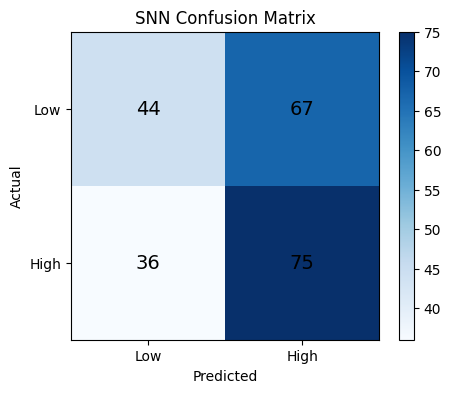

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

plt.imshow(cm, cmap="Blues")

plt.colorbar()

plt.xticks([0,1], ["Low","High"])
plt.yticks([0,1], ["Low","High"])

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
            color="black",
            fontsize=14
        )

plt.title("SNN Confusion Matrix")

plt.show()

Step 22 — Training Curves

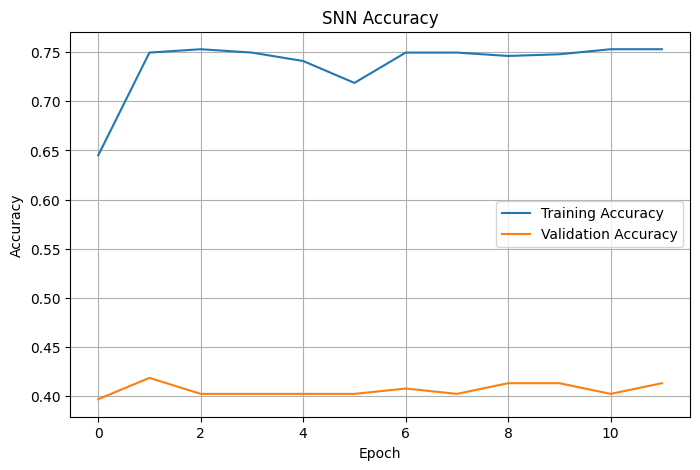

In [24]:
plt.figure(figsize=(8,5))

plt.plot(train_accs, label="Training Accuracy")

plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("SNN Accuracy")

plt.legend()

plt.grid(True)

plt.show()

Loss

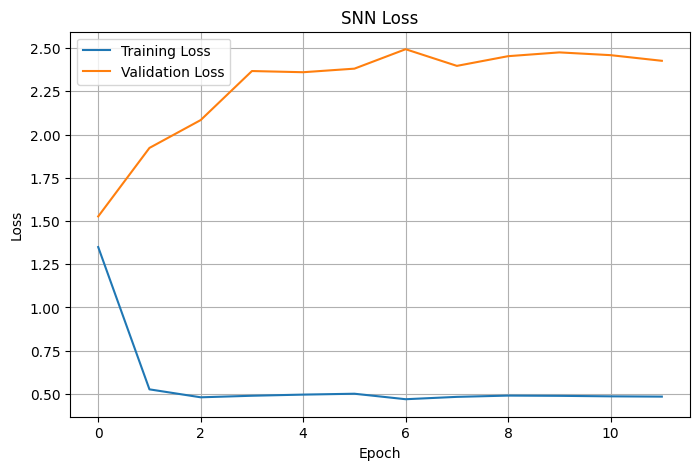

In [25]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")

plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("SNN Loss")

plt.legend()

plt.grid(True)

plt.show()

In [26]:
model.load_state_dict(torch.load("best_snn.pth"))

model.eval()

print("Best model loaded.")

Best model loaded.


In [27]:
y_true = []
y_pred = []
y_prob = []

model.eval()

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        spk_rec, mem_rec = model(X_batch)

        output = mem_rec.mean(dim=0)

        prob = torch.softmax(output, dim=1)

        pred = output.argmax(dim=1)

        y_true.extend(y_batch.cpu().numpy())

        y_pred.extend(pred.cpu().numpy())

        y_prob.extend(prob[:,1].cpu().numpy())

In [28]:
from sklearn.metrics import *

accuracy = accuracy_score(y_true,y_pred)

precision = precision_score(y_true,y_pred)

recall = recall_score(y_true,y_pred)

f1 = f1_score(y_true,y_pred)

roc_auc = roc_auc_score(y_true,y_prob)

print("Accuracy :",accuracy)

print("Precision:",precision)

print("Recall   :",recall)

print("F1       :",f1)

print("ROC AUC  :",roc_auc)

print()

print(classification_report(y_true,y_pred))

print(confusion_matrix(y_true,y_pred))

Accuracy : 0.536036036036036
Precision: 0.528169014084507
Recall   : 0.6756756756756757
F1       : 0.5928853754940712
ROC AUC  : 0.3898222546871195

              precision    recall  f1-score   support

           0       0.55      0.40      0.46       111
           1       0.53      0.68      0.59       111

    accuracy                           0.54       222
   macro avg       0.54      0.54      0.53       222
weighted avg       0.54      0.54      0.53       222

[[44 67]
 [36 75]]


In [29]:
import pandas as pd

results = pd.DataFrame({

    "Model": [
        "EEGNet",
        "EEG Conformer",
        "Spiking Neural Network"
    ],

    "Accuracy": [
        0.9414,
        0.6667,
        0.5360
    ],

    "Precision": [
        0.9804,
        0.6000,
        0.5282
    ],

    "Recall": [
        0.9009,
        1.0000,
        0.6757
    ],

    "F1-score": [
        0.9390,
        0.7500,
        0.5929
    ],

    "ROC-AUC": [
        0.9622,
        0.3573,
        0.3898
    ]

})

results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,EEGNet,0.9414,0.9804,0.9009,0.9390,0.9622
1,EEG Conformer,0.6667,0.6000,1.0000,0.7500,0.3573
2,Spiking Neural Network,0.5360,0.5282,0.6757,0.5929,0.3898


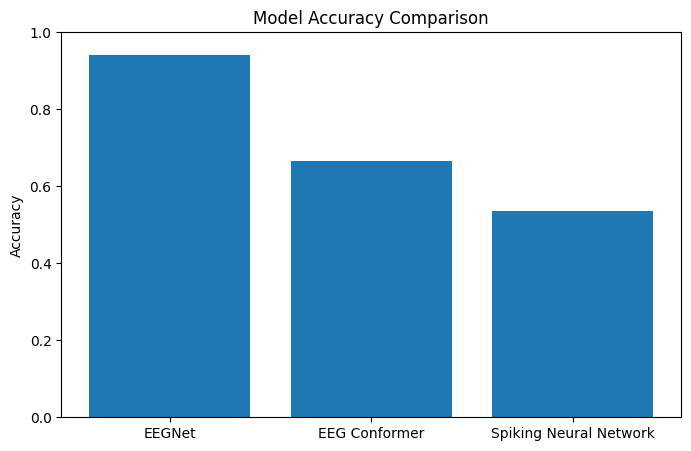

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"])

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.ylim(0,1)

plt.show()

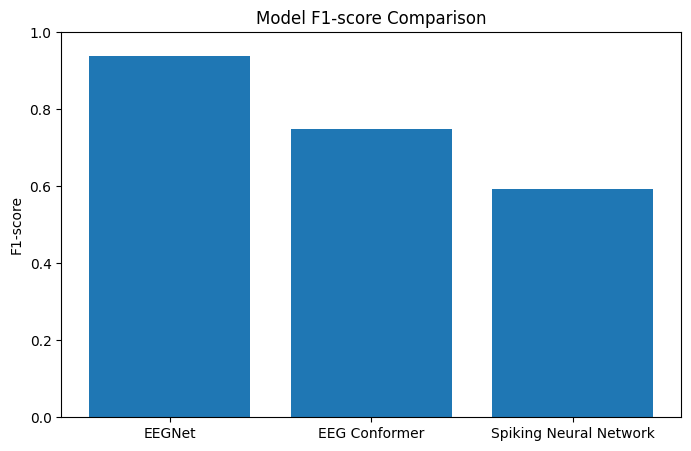

In [31]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["F1-score"])

plt.ylabel("F1-score")
plt.title("Model F1-score Comparison")

plt.ylim(0,1)

plt.show()

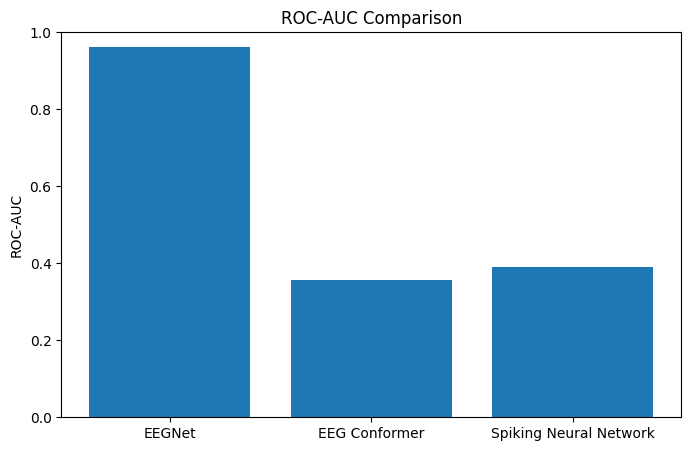

In [32]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["ROC-AUC"])

plt.ylabel("ROC-AUC")
plt.title("ROC-AUC Comparison")

plt.ylim(0,1)

plt.show()

In [33]:
results.sort_values("Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,EEGNet,0.9414,0.9804,0.9009,0.9390,0.9622
1,EEG Conformer,0.6667,0.6000,1.0000,0.7500,0.3573
2,Spiking Neural Network,0.5360,0.5282,0.6757,0.5929,0.3898
